# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

##  Проверка гипотезы о времени активности пользователей Яндекс Книг

- Автор: Басс Наталья
- Дата: 12.08.2026

## Цели и задачи проекта

**Цель проекта** — проанализировать активность пользователей Яндекс Книг из Москвы и Санкт-Петербурга и проверить гипотезу о том, что пользователи из Санкт-Петербурга в среднем проводят больше времени за чтением и прослушиванием книг, чем пользователи из Москвы.

**Задачи проекта**:

- загрузить и изучить подготовленные данные
- проверить данные на наличие дубликатов и пересечений пользователей между городами
- сравнить размеры групп пользователей Москвы и Санкт-Петербурга
- рассчитать основные описательные статистики времени активности
- изучить распределение часов активности пользователей
- сформулировать нулевую и альтернативную гипотезы
- провести односторонний t-тест для двух независимых выборок;
- интерпретировать полученное p-value
- сформулировать итоговые выводы и подготовить аналитическую записку

## Описание данных

Для анализа используется файл `yandex_knigi_data.csv`, содержащий данные об активности пользователей Яндекс Книг из Москвы и Санкт-Петербурга.

В таблице представлены следующие поля:

- `city` — город пользователя: Москва или Санкт-Петербург;
- `puid` — уникальный идентификатор пользователя;
-`hours` — суммарное количество часов, которое пользователь провёл за чтением и прослушиванием книг в приложении.

## Содержимое проекта:

### Загрузка данных и знакомство с ними
- загрузка файла
- изучение структуры и типов данных
- удаление технического столбца

### Проверка и подготовка данных
- поиск полных дубликатов
- проверка повторяющихся идентификаторов пользователей
- выявление пользователей, присутствующих одновременно в Москве и Санкт-Петербурге
- формирование независимых выборок

### Исследовательский анализ
- сравнение размеров групп
- расчёт долей пользователей по городам
- анализ статистики
- изучение распределения часов активности

### Проверка статистической гипотезы
- формулировка нулевой и альтернативной гипотез
- выбор уровня статистической значимости
- проведение одностороннего t-теста Уэлча
- анализ полученного p-value

### Формирование выводов
- интерпретация результатов статистического теста
- подготовка аналитической записки

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import (proportion_effectsize, proportions_ztest)

In [2]:
# Загружаем данные пользователей Яндекс Книг
books_data = pd.read_csv('/datasets/yandex_knigi_data.csv')

# Выводим первые 5 строк
books_data.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
# Выводим информацию о таблице
books_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [4]:
# Удалим столбец (не используется в анализе)
books_data = books_data.drop(columns='Unnamed: 0')

# Выводим первые 5 строк
books_data.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [5]:
# Выводим результаты проверки дубликатов
print('Дубликаты по puid:', books_data['puid'].duplicated().sum())
print('Полные дубликаты строк:', books_data.duplicated().sum())

Дубликаты по puid: 244
Полные дубликаты строк: 0


In [6]:
# Посчитаем количество разных городов для каждого пользователя
user_city = (books_data
    .groupby('puid')['city']
    .nunique())

# Считаем пользователей (более чем в одном городе)
above_users = user_city[user_city > 1].index

# Выводим результат 
print('Количество пользователей одновременно в двух городах:',len(above_users))

Количество пользователей одновременно в двух городах: 244


In [7]:
# Выводим пользователей (одновреммено в двух городах)
books_data[
    books_data['puid'].isin(above_users)].sort_values('puid').head(20)

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
6279,Санкт-Петербург,10597984,9.041320
150,Москва,10815097,9.086655
6283,Санкт-Петербург,10815097,0.323291
187,Москва,13626259,21.104167
6300,Санкт-Петербург,13626259,1.648434


In [8]:
# Исключаем пользователей, которые одновременно есть в двух городах
books_clean = books_data[~books_data['puid'].isin(above_users)].copy()

# Проверяем результат
print('Количество пользователей после очистки:',len(books_clean))

# Проверяем рультат (дубликаты)
print('Дубликаты по puid после очистки:',books_clean['puid'].duplicated().sum())

Количество пользователей после очистки: 8296
Дубликаты по puid после очистки: 0


In [9]:
# Считаем количество пользователей в каждом городе после очистки
group_comparison = (books_clean['city']
    .value_counts()
    .to_frame(name='users'))

# Считаем долю пользователей каждого города
group_comparison['share'] = ( group_comparison['users']/ group_comparison['users'].sum())

# Выводим результат
group_comparison

,users,share
Москва,5990,0.722035
Санкт-Петербург,2306,0.277965


In [10]:
# Считаем описательные статистики часов активности для городов
group_stats = (books_clean
    .groupby('city')['hours']
    .describe())

# Выводим рузультат
group_stats

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,5990.0,10.848192,36.925622,0.000022,0.057042,0.888232,5.933439,857.209373
Санкт-Петербург,2306.0,11.264433,39.831755,0.000025,0.060173,0.875355,6.138424,978.764775


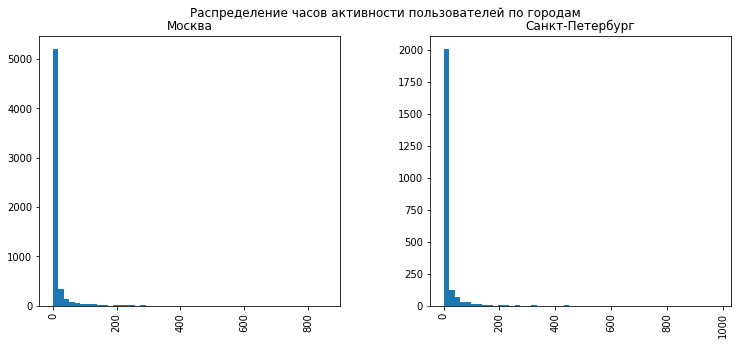

In [11]:
# Построим гистограммы распределения часов активности
books_clean.hist(
    column='hours',
    by='city',
    bins=50,
    figsize=(12, 5))

# Добавляемзаголовок графиков
plt.suptitle('Распределение часов активности пользователей по городам')

# Выводим графики
plt.show()

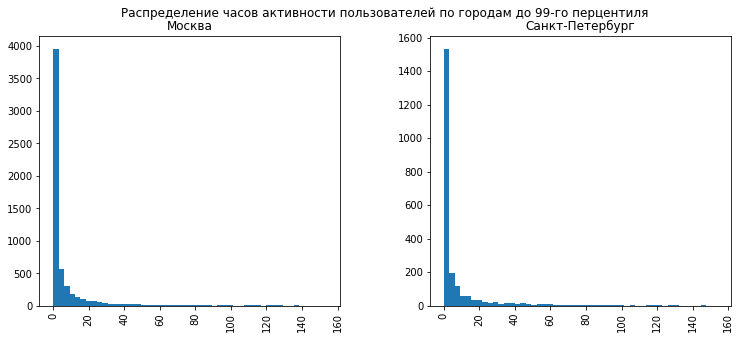

In [12]:
# Считаем 99-й перцентиль часов активности 
hours_limit = books_clean['hours'].quantile(0.99)

# Строим распределения часов активности до 99-го перцентиля
books_clean.hist(
    column='hours',
    by='city',
    bins=50,
    figsize=(12, 5),
    range=(0, hours_limit))

# Добавляем заголовок графиков
plt.suptitle('Распределение часов активности пользователей по городам до 99-го перцентиля')

# Выводим графики
plt.show()

**Промежуточный вывод:**

- В исходных данных содержалось 8784 наблюдения. Полных дубликатов строк не обнаружено, только выявлено 244 повторяющихся идентификатора пользователей. Проверка показала, что эти пользователи одновременно присутствуют в данных Москвы и Санкт-Петербурга. Для обеспечения независимости сравниваемых групп они были исключены из дальнейшего анализа. После очистки осталось 8296 пользователей: 5990 из Москвы и 2306 из Санкт-Петербурга. Таким образом, группы различаются по размеру - Москва(72% пользователей), Санкт-Петербург(около 28% пользователей).
- Среднее время активности пользователей Санкт-Петербурга немного выше, чем пользователей Москвы: 11,26 часа против 10,85 часа. При этом медианные значения практически одинаковы — около 0,9 часа в обоих городах.
- Распределения часов активности в обеих группах сильно скошены вправо, большинство пользователей проводят в сервисе относительно немного времени, однако встречаются отдельные пользователи с очень высокой активностью. Это также объясняет заметную разницу между средним и медианой и высокий разброс значений.
- На этапе описательного анализа можно заметить небольшое преимущество Санкт-Петербурга по среднему времени активности, однако необходимо провести статистический тест, чтобы определить, является ли это различие статистически значимым.

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [13]:
# Формируем выборку часов активности пользователей Санкт-Петербурга
metric_spb = books_clean[
    books_clean.city == 'Санкт-Петербург']['hours']

# Формируем выборку часов активности пользователей Москвы
metric_moscow = books_clean[
    books_clean.city == 'Москва']['hours']

# Задаём уровень статистической значимости
alpha = 0.05

# Проводим односторонний t-тест Уэлча
# Альтернативная гипотеза предполагает, что среднее в Санкт-Петербурге больше среднего в Москве
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_spb,
    metric_moscow,
    equal_var=False,
    alternative='greater')

# Сравниваем p-value с уровнем статистической значимости
if p_value_welch_ttest > alpha:
    print(f'p-value теста Уэлча = {p_value_welch_ttest:.4f}')
    print('Не удалось отвергнуть нулевую гипотезу')
    print('Интерпретация: недостаточно оснований утверждать, '
          'что пользователи Санкт-Петербурга проводят в приложении '
          'больше времени, чем пользователи Москвы')
else:
    print(f'p-value теста Уэлча = {p_value_welch_ttest:.4f}')
    print('Отвергаем нулевую гипотезу')
    print('Интерпретация: пользователи Санкт-Петербурга проводят '
          'в приложении статистически значимо больше времени, '
          'чем пользователи Москвы')

p-value теста Уэлча = 0.3318
Не удалось отвергнуть нулевую гипотезу
Интерпретация: недостаточно оснований утверждать, что пользователи Санкт-Петербурга проводят в приложении больше времени, чем пользователи Москвы


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



----

**Аналитическая записка**

- Для проверки гипотезы использован односторонний t-тест Уэлча для двух независимых выборок. Тест Уэлча выбран, поскольку размеры групп различаются, а дисперсии могут быть неодинаковыми. Уровень статистической значимости установлен на уровне α = 0,05.
- Нулевая гипотеза предполагала, что среднее время активности пользователей Санкт-Петербурга не больше, чем пользователей Москвы. Альтернативная гипотеза — что пользователи Санкт-Петербурга в среднем проводят в приложении больше времени.
- По результатам теста получено p-value = 0,33.Поскольку p-value > α (0,33 > 0,05), не получилось отвергнуть нулевую гипотезу. Полученных данных недостаточно, чтобы статистически подтвердить, что пользователи Санкт-Петербурга в среднем проводят за чтением и прослушиванием книг больше времени, чем пользователи Москвы.
- Хотя среднее время активности в Санкт-Петербурге немного выше — 11,26 часа, а в Москве -  10,85 часа, разница между средними невелика. Также в обеих группах наблюдается высокий разброс значений и пользователи с очень высокой активностью. Эти факторы могут объяснять отсутствие статистически значимого различия между группами.

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



**Цель исследования:** оценить корректность проведения A/B-теста interface_eu_test и определить, привёл ли новый упрощённый интерфейс интернет-магазина к статистически значимому увеличению конверсии зарегистрированных пользователей в покупку в течение первых семи дней после регистрации. Также необходимо проверить, достиг ли наблюдаемый эффект заявленного в техническом задании уровня — увеличения конверсии минимум на 3 процентных пункта

## 2. Загрузите данные, оцените их целостность.


In [14]:
# Загружаем данные об участниках A/B-тестов
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
# Загружаем данные о событиях пользователей
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [15]:
# Выводим информацию о таблице участников тестов
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [16]:
# Выводим первые 5 строк таблицы участников тестов
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [17]:
# Выводим информацию о таблице событий
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [18]:
# Выводим первые 5 строк таблицы событий
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [19]:
# Выводим размеры таблиц
print('Размер таблицы participants:', participants.shape)
print('Размер таблицы events:', events.shape)

Размер таблицы participants: (14525, 4)
Размер таблицы events: (787286, 4)


In [20]:
# Проверим количество пропущенных значений в таблице participants
participants.isna().sum()

user_id    0
group      0
ab_test    0
device     0
dtype: int64

In [21]:
# Проверим количество пропущенных значений в таблице events
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64

In [22]:
# Проверим количество полных дубликатов в таблицах
print('Полные дубликаты в participants:', participants.duplicated().sum())
print('Полные дубликаты в events:', events.duplicated().sum())

Полные дубликаты в participants: 0
Полные дубликаты в events: 36318


In [23]:
# Удаляем полные дубликаты из таблицы событий
events = events.drop_duplicates().reset_index(drop=True)

# Проверяем результат
print('Полные дубликаты в events после очистки:', events.duplicated().sum())
print('Размер таблицы events после очистки:', events.shape)

Полные дубликаты в events после очистки: 0
Размер таблицы events после очистки: (750968, 4)


In [24]:
# Проверяем заполненность details для разных типов событий
details_check = (
    events
    .groupby('event_name')['details']
    .agg( total='size',
        filled=lambda x: x.notna().sum(),
        missing=lambda x: x.isna().sum()))

# Выводим результат
details_check

,total,filled,missing
event_name,,,
End of Black Friday Ads Campaign,1,1,0
Start of CIS New Year Gift Lottery,1,1,0
Start of Christmas&New Year Promo,1,1,0
login,228196,0,228196
product_cart,90388,0,90388
product_page,187479,0,187479
purchase,100719,100719,0
registration,144183,144183,0


In [25]:
# Проверим начало и конец периода событий
print('Начало периода:', events['event_dt'].min())
print('Конец периода:', events['event_dt'].max())

Начало периода: 2020-12-01 00:00:00
Конец периода: 2020-12-31 23:59:48


In [26]:
# Проверим какие A/B-тесты представлены в данных
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

In [27]:
# Проверим распределение участников по группам
participants['group'].value_counts()

A    8130
B    6395
Name: group, dtype: int64

In [28]:
# Проверим распределение участников по устройствам
participants['device'].value_counts()

Android    6484
PC         3717
iPhone     2858
Mac        1466
Name: device, dtype: int64

In [29]:
# Проверяем типы пользовательских событий
events['event_name'].value_counts()

login                                 228196
product_page                          187479
registration                          144183
purchase                              100719
product_cart                           90388
End of Black Friday Ads Campaign           1
Start of Christmas&New Year Promo          1
Start of CIS New Year Gift Lottery         1
Name: event_name, dtype: int64

**Промежуточный вывод:**

- В таблице participants содержится 14525 записей о пользователях, участвующих в двух A/B-тестах. Пропущенные значения и полные дубликаты в таблице отсутствуют. В данных представлены тесты interface_eu_test и recommender_system_test.
- Таблица events вначале содержала 787286 событий. В ней было обнаружено 36318 полных дубликатов, которые были удалены. После очистки осталось 750968 событий.
- Пропущенные значения обнаружены только в столбце details. Проверка показала, что они имеют системный характер: поле заполнено для событий registration и purchase, а для login, product_page и product_cart не заполняется. Поэтому такие пропуски не являются ошибкой и не требуют обработки.
- Данные о событиях представлены за период с 1 по 31 декабря 2020 года. Помимо пользовательских действий registration, login, product_page, product_cart и purchase, в данных присутствуют отдельные служебные события, связанные с рекламными кампаниями.
- После удаления полных дубликатов данные можно использовать для дальнейшего анализа. Следующим этапом необходимо отобрать пользователей теста interface_eu_test и проверить корректность его проведения: размеры групп A и B, пересечения пользователей между группами и участие пользователей в других тестах.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [30]:
# Выделяем пользователей теста interface_eu_test
interface_test = participants[
    participants['ab_test'] == 'interface_eu_test'].copy()

# Выводим первые 5 строк
interface_test.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android


In [31]:
# Выводим количество записей и уникальных пользователей теста
print('Количество записей:', len(interface_test))
print('Количество уникальных пользователей:', interface_test['user_id'].nunique())

Количество записей: 10850
Количество уникальных пользователей: 10850


In [32]:
# Проверяем группы пользователей в тесте
interface_test['group'].value_counts()

B    5467
A    5383
Name: group, dtype: int64

In [33]:
# Выводим уникальные названия групп
print('Группы теста:', interface_test['group'].unique())

Группы теста: ['B' 'A']


In [34]:
# Считаем количество уникальных пользователей в каждой группе
group_sizes = (
    interface_test
    .groupby('group')['user_id']
    .nunique())

# Выводим результат
group_sizes

group
A    5383
B    5467
Name: user_id, dtype: int64

In [35]:
# Считаем долю пользователей каждой группы
group_shares = (group_sizes / group_sizes.sum())

# Выводим результат
group_shares

group
A    0.496129
B    0.503871
Name: user_id, dtype: float64

In [36]:
# Считаем количество разных групп для каждого пользователя
user_group_count = (
    interface_test
    .groupby('user_id')['group']
    .nunique())

# Находим пользователей, попавших более чем в одну группу
group_overlap = user_group_count[user_group_count > 1].index

# Выводим количество пересечений между группами
print('Пользователей одновременно в группах A и B:', len(group_overlap))

Пользователей одновременно в группах A и B: 0


In [37]:
# Получаем пользователей конкурирующего теста
recom_users = participants[
    participants['ab_test'] == 'recommender_system_test']['user_id'].unique()

# Получаем пользователей теста interface_eu_test
interface_users = interface_test['user_id'].unique()

# Пользователи участвующие одновременно в двух тестах
test_overlap = set(interface_users) & set(recom_users)

# Выводим количество пересекающихся пользователей
print('Пользователей одновременно в двух тестах:', len(test_overlap))

Пользователей одновременно в двух тестах: 887


In [38]:
# Считаем пользователей тестовой группы B конкурирующего теста
recom_b_users = participants[
    (participants['ab_test'] == 'recommender_system_test') &
    (participants['group'] == 'B')]['user_id'].unique()

# Находим пользователей interface_eu_test, которые одновременно участвуют в тестовой группе B другого теста
test_group_overlap = (set(interface_users) & set(recom_b_users))

# Выводим результат
print( 'Пользователей interface_eu_test одновременно '
       'в тестовой группе B конкурирующего теста:', len(test_group_overlap))

Пользователей interface_eu_test одновременно в тестовой группе B конкурирующего теста: 222


In [39]:
# Считаем пользователей тестовой группы B interface_eu_test
interface_b_users = interface_test[interface_test['group'] == 'B']['user_id'].unique()

# Получаем пользователей тестовой группы B recommender_system_test
recom_b_users = participants[
    (participants['ab_test'] == 'recommender_system_test') &
    (participants['group'] == 'B')]['user_id'].unique()

# Находим пользователей, которые одновременно находятся в тестовых группах B обоих экспериментов
double_b_users = (set(interface_b_users) & set(recom_b_users))

# Выводим результат
print('Пользователей одновременно в тестовых группах B обоих тестов:', len(double_b_users))

Пользователей одновременно в тестовых группах B обоих тестов: 116


In [40]:
# Исключаем участников interface_eu_test которые находятся в группе B конкурирующего теста
interface_test_clean = interface_test[
    ~interface_test['user_id'].isin(test_group_overlap)].copy()

# Проверяем количество пользователей после очистки
print('Количество пользователей после очистки:',
    interface_test_clean['user_id'].nunique())

# Проверяем по группам 
interface_test_clean['group'].value_counts()

Количество пользователей после очистки: 10628


B    5351
A    5277
Name: group, dtype: int64

In [41]:
# Считаем доли пользователей по группам после очистки
group_shares_clean = (
    interface_test_clean['group']
    .value_counts(normalize=True))

# Выводим результат
group_shares_clean

B    0.503481
A    0.496519
Name: group, dtype: float64

**Промежуточный вывод:**

- В тесте interface_eu_test участвуют 10850 уникальных пользователей. Группы A и B изначально распределены практически равномерно: 49,61% и 50,39% соответственно. Пересечений между группами внутри теста не обнаружено.
- При проверке конкурирующего теста выявлено 222 пользователя, которые одновременно участвовали в interface_eu_test и находились в группе B recommender_system_test. Они были исключены из дальнейшего анализа. После очистки осталось 10628 пользователей: 5277 в группе A и 5351 в группе B. Распределение групп осталось практически равномерным.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [42]:
# Получаем идентификаторы пользователей interface_eu_test
test_users = interface_test_clean['user_id'].unique()

# Оставляем только события пользователей, участвующих в изучаемом тесте
test_events = events[events['user_id'].isin(test_users)].copy()

# Выводим первые 5 строк
test_events.head()

,user_id,event_dt,event_name,details
64143,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64414,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66047,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67326,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67382,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


In [43]:
# Выводим количество событий после отбора пользователей теста
print('Количество событий пользователей теста:', len(test_events))

# Выводим количество уникальных пользователей с событиями
print('Количество уникальных пользователей с событиями:', test_events['user_id'].nunique())

Количество событий пользователей теста: 72298
Количество уникальных пользователей с событиями: 10628


In [44]:
# Сравниваем количество участников теста и количество пользователей, для которых есть события
print('Всего участников теста:', interface_test_clean['user_id'].nunique())
print('Участников теста с событиями:', test_events['user_id'].nunique())

Всего участников теста: 10628
Участников теста с событиями: 10628


**Промежуточный вывод:**

- После отбора событий пользователей interface_eu_test в таблице осталось 72298 событий. Все 10 628 участников очищенной выборки имеют хотя бы одно событие в таблице активности.
- То есть пользователей, которые числятся участниками теста, но полностью отсутствуют в events, нет. Данные можно использовать для дальнейшего анализа пользовательской активности.

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [45]:
# Создаем таблицу событий пользователей interface_eu_test
test_events = events[
    events['user_id'].isin(test_users)].copy()

# Выводим результат
print(test_events.columns)

Index(['user_id', 'event_dt', 'event_name', 'details'], dtype='object')


In [46]:
# Находим дату и время регистрации каждого пользователя
registration_time = (
    test_events[test_events['event_name'] == 'registration']
    .groupby('user_id', as_index=False)
    .agg(registration_dt=('event_dt', 'min')))

# Выводим первые 5 строк
registration_time.head()

,user_id,registration_dt
0,0002CE61FF2C4011,2020-12-07 04:37:31
1,001E72F50D1C48FA,2020-12-17 15:44:05
2,002412F1EB3F6E38,2020-12-09 09:36:50
3,002540BE89C930FB,2020-12-08 18:06:07
4,0031F1B5E9FBF708,2020-12-14 00:47:10


In [47]:
# Добавим дату и время регистрации к событиям пользователей
test_events = test_events.merge(
    registration_time,
    on='user_id',
    how='left')

# Рассчитываем лайфтайм события после регистрации
test_events['lifetime'] = (
    test_events['event_dt'] - test_events['registration_dt'])

# Выводим первые 5 строк
test_events.head()

,user_id,event_dt,event_name,details,registration_dt,lifetime
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0 days
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0 days
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0 days
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0 days
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0 days


In [48]:
# Оставим события совершенные в первых 7 суток после регистрации
test_events_7d = test_events[
    (test_events['lifetime'] >= pd.Timedelta(0)) &
    (test_events['lifetime'] <= pd.Timedelta(days=7))].copy()

# Проверяем результат
print('Количество событий в пределах 7 дней:', len(test_events_7d))
print('Количество пользователей:', test_events_7d['user_id'].nunique())

Количество событий в пределах 7 дней: 62383
Количество пользователей: 10628


**Промежуточный вывод:**

- Для каждого события рассчитан лайфтайм - время с момента регистрации пользователя). В анализ оставлены только события, совершённые в течение первых 7 суток после регистрации. После фильтрации осталось 62383 события от 10628 пользователей.

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [49]:
# Задаём параметры теста
conversion = 0.30
mde = 0.03
alpha = 0.05
power = 0.80

# Рассчитываем ожидаемую конверсию с учётом MDE
target_conversion = conversion + mde

# Рассчитываем размер эффекта
effect_size = proportion_effectsize(
    conversion,
    target_conversion)

# Рассчитываем необходимый размер выборки на одну группу
sample_size = NormalIndPower().solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1)

# Округляем размер выборки в большую сторону
sample_size = ceil(sample_size)

# Выводим результат
print('Необходимый размер выборки на одну группу:', sample_size)
print('Необходимый размер выборки всего:', sample_size * 2)

Необходимый размер выборки на одну группу: 3762
Необходимый размер выборки всего: 7524


In [50]:
# Считаем фактическое количество пользователей в каждой группе
actual_group_sizes = (
    interface_test_clean
    .groupby('group')['user_id']
    .nunique())

# Выводим результат
actual_group_sizes

group
A    5277
B    5351
Name: user_id, dtype: int64

In [51]:
# Проверяем достаточность фактической выборки
if (actual_group_sizes >= sample_size).all():
    print('Размер выборки достаточен')
else:
    print('Размер выборки недостаточен')

Размер выборки достаточен


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [52]:
# Добавляем группу A/B к событиям пользователей
test_events_7d = test_events_7d.merge(
    interface_test_clean[['user_id', 'group']],
    on='user_id',
    how='left')

# Считаем общее количество пользователей в каждой группе
total_users = (
    interface_test_clean
    .groupby('group')['user_id']
    .nunique())

# Считаем количество пользователей, совершивших покупку в течение первых 7 дней
buyers = (
    test_events_7d[test_events_7d['event_name'] == 'purchase']
    .groupby('group')['user_id']
    .nunique())

# Объединяем результаты в одну таблицу
group_results = pd.DataFrame({
    'total_users': total_users,
    'buyers': buyers})

# Выводим результат
group_results

,total_users,buyers
group,,
A,5277,1454
B,5351,1579


In [53]:
# Рассчитываем конверсию в покупку для каждой группы
group_results['conversion'] = (
    group_results['buyers'] /
    group_results['total_users'])

# Выводим результат
group_results

,total_users,buyers,conversion
group,,,
A,5277,1454,0.275535
B,5351,1579,0.295085


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Предварительный общий вывод:**

- В тестовой группе B пользовательская активность по целевой метрике выше, чем в контрольной группе A. Конверсия в покупку составляет около 29,5% в группе B против 27,6% в группе A, то есть прирост составляет примерно 1,95 процентного пункта.
- При этом наблюдаемый прирост меньше ожидаемого эффекта в 3 процентных пункта. На данном этапе можно говорить только о предварительном улучшении метрики в тестовой группе; для окончательного вывода необходимо проверить статистическую значимость различий между группами.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [54]:
# Размеры групп A и B
n_a = group_results.loc['A', 'total_users']
n_b = group_results.loc['B', 'total_users']

# Количество пользователей, совершивших покупку
m_a = group_results.loc['A', 'buyers']
m_b = group_results.loc['B', 'buyers']

# Рассчитываем конверсию в покупку для каждой группы
p_a = m_a / n_a
p_b = m_b / n_b

# Выводим основные показатели
print(f'n_a={n_a}, n_b={n_b}')
print(f'm_a={m_a}, m_b={m_b}')
print(f'p_a={p_a:.3f}, p_b={p_b:.3f}')

# Проверяем предпосылку о достаточном количестве данных
if (
    (m_a >= 5) and
    (n_a - m_a >= 5) and
    (m_b >= 5) and
    (n_b - m_b >= 5)):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')


# Задаём уровень статистической значимости
alpha = 0.05


# Проводим односторонний z-тест пропорций
# H0: конверсия группы B не выше конверсии группы A
# H1: конверсия группы B выше конверсии группы A

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller')

# Выводим p-value
print(f'pvalue={p_value_ztest}')

# Принимаем решение по статистическому тесту
if p_value_ztest > alpha:
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print('Отвергаем нулевую гипотезу')

# Формируем интерпретацию результата
text_interpretation = (
    'статистически значимо увеличилась'
    if p_value_ztest < alpha
    else 'статистически значимо не увеличилась')

# Рассчитываем изменение конверсии в процентных пунктах
conversion_difference = (p_b - p_a) * 100

# Выводим результат
print(
    f'В тестовой группе B конверсия в покупку '
    f'{text_interpretation}. '
    f'Конверсия группы A составила {p_a:.2%}, '
    f'группы B — {p_b:.2%}. '
    f'Изменение составило {conversion_difference:.2f} п.п.'
)

n_a=5277, n_b=5351
m_a=1454, m_b=1579
p_a=0.276, p_b=0.295
Предпосылка о достаточном количестве данных выполняется!
pvalue=0.01282747194234516
Отвергаем нулевую гипотезу
В тестовой группе B конверсия в покупку статистически значимо увеличилась. Конверсия группы A составила 27.55%, группы B — 29.51%. Изменение составило 1.95 п.п.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

**Выводы:** 
- В группе B конверсия в покупку составила 29,51%, а в контрольной группе A — 27,55%. Абсолютное увеличение конверсии составило 1,95 процентного пункта.
- Односторонний z-тест пропорций показал статистически значимое различие между группами: p-value = 0,0128, что меньше уровня значимости α = 0,05. Следовательно, нулевая гипотеза об отсутствии увеличения конверсии отвергается: новый интерфейс статистически значимо увеличил конверсию в покупку.
- Однако фактический прирост составил только 1,95 п.п., что меньше заявленного в техническом задании эффекта в 3 п.п. Таким образом, новый интерфейс оказал положительное статистически значимое влияние на конверсию, но исходная продуктовая гипотеза об увеличении конверсии как минимум на 3 процентных пункта не подтвердилась.